# Databricks Sales Analysis Project - Superstore Kaggle Dataset

# Día 1: Carga y Exploración de Datos
- Cargamos la tabla superstore desde Data Ingestion usando el entorno serverless.
- Exploramos esquema y estadísticas básicas.
- Siguientes pasos: Limpieza y transformaciones (Día 2).

# Import & Dependencies

In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, to_date, avg, lit, sqrt, mean


In [0]:
# Inicia la sesión Spark (usa el entorno serverless)
spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()

In [0]:
# Carga la tabla superstore desde el catálogo
df = spark.table("default.superstore")

# Muestra las primeras 5 filas
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156|2016-11-08|2016-11-11|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [0]:
# Muestra el esquema (columnas y tipos)
df.printSchema()

# Estadísticas básicas (count, mean, min, max)
df.describe().show()

# Conteo de filas
print("Número de filas:", df.count())

root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)

+-------+------------------+--------------+--------------+-----------+------------------+-----------+-------------+--------+-------+------------------+------

# Día 2: Limpieza y Transformación de Datos con Delta Lake
- Objetivo: Limpiar el dataset superstore, transformar datos (e.g., ventas por región), y guardarlos en Delta Lake.
- Pasos: Manejar nulos, corregir tipos, agregar columnas, y usar Delta Lake para almacenamiento fiable.
- Siguientes pasos: Análisis y ML (Día 3).

In [0]:
print("Entorno listo")

Entorno listo


In [0]:
# Inicia la sesión Spark
spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()

# Carga la tabla superstore
df = spark.table("default.superstore")

In [0]:
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|Row ID|      Order ID|Order Date| Ship Date|     Ship Mode|Customer ID|  Customer Name|  Segment|      Country|           City|     State|Postal Code|Region|     Product ID|       Category|Sub-Category|        Product Name|   Sales|Quantity|Discount|  Profit|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+
|     1|CA-2016-152156|2016-11-08|2016-11-11|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Kentucky|      42420| South|FUR-BO-10001798|      Furniture|   Bookcases|Bush Somerset 

In [0]:

# Ajusta Profit: casting a double y rellena nulos con 0 (usando df.na.fill)
df_clean = df.withColumn("Profit", col("Profit").cast("double"))
df_clean = df_clean.na.fill({"Profit": 0})  # Rellena nulos solo en Profit con 0

# Crea Profit_Adjusted (convierte negativos a 0)
df_clean = df_clean.withColumn("Profit_Adjusted", when(col("Profit") < 0, 0).otherwise(col("Profit")))

# Muestra las primeras 5 filas para verificar
df_clean.show(5, truncate=False)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+
|Row ID|Order ID      |Order Date|Ship Date |Ship Mode     |Customer ID|Customer Name  |Segment  |Country      |City           |State     |Postal Code|Region|Product ID     |Category       |Sub-Category|Product Name                                               |Sales   |Quantity|Discount|Profit  |Profit_Adjusted|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+
|1     |CA-2016-152156|2016-11-08|2016-11-11|Second 

In [0]:
df_clean.printSchema()

root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = false)
 |-- Profit_Adjusted: double (nullable = false)



In [0]:

# Agrega una columna de ventas totales por fila (Sales * Quantity)
df_transformed = df_clean.withColumn("Total_Sales", col("Sales") * col("Quantity"))

# Muestra las primeras 5 filas para verificar
df_transformed.show(5, truncate=False)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+-----------+
|Row ID|Order ID      |Order Date|Ship Date |Ship Mode     |Customer ID|Customer Name  |Segment  |Country      |City           |State     |Postal Code|Region|Product ID     |Category       |Sub-Category|Product Name                                               |Sales   |Quantity|Discount|Profit  |Profit_Adjusted|Total_Sales|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+-----------+
|1     |CA-2016-

In [0]:
df_transformed.printSchema()

root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = false)
 |-- Profit_Adjusted: double (nullable = false)
 |-- Total_Sales: double (nullable = true)



In [0]:

# Calcula ventas totales por región
sales_by_region = df_transformed.groupBy("Region").agg({"Total_Sales": "sum"}).withColumnRenamed("sum(Total_Sales)", "Total_Sales_Region")

# Ordena de mayor a menor
sales_by_region.orderBy(col("Total_Sales_Region").desc()).show()

+-------+------------------+
| Region|Total_Sales_Region|
+-------+------------------+
|   West|3595227.5234999964|
|   East| 3379326.253999996|
|Central| 2475832.944399999|
|  South|2037675.3500000036|
+-------+------------------+



In [0]:
df_transformed.printSchema()

root
 |-- Row ID: long (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = false)
 |-- Profit_Adjusted: double (nullable = false)
 |-- Total_Sales: double (nullable = true)



In [0]:
# Renombra columnas con espacios a guion bajo
df_transformed_renamed = df_transformed.withColumnRenamed("Row ID", "Row_ID") \
                                      .withColumnRenamed("Order ID", "Order_ID") \
                                      .withColumnRenamed("Order Date", "Order_Date") \
                                      .withColumnRenamed("Ship Date", "Ship_Date") \
                                      .withColumnRenamed("Ship Mode", "Ship_Mode") \
                                      .withColumnRenamed("Customer ID", "Customer_ID") \
                                      .withColumnRenamed("Customer Name", "Customer_Name") \
                                      .withColumnRenamed("Postal Code", "Postal_Code") \
                                      .withColumnRenamed("Product ID", "Product_ID") \
                                      .withColumnRenamed("Product Name", "Product_Name")

# Muestra el esquema para verificar
df_transformed_renamed.printSchema()

root
 |-- Row_ID: long (nullable = true)
 |-- Order_ID: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Ship_Date: date (nullable = true)
 |-- Ship_Mode: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal_Code: long (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = false)
 |-- Profit_Adjusted: double (nullable = false)
 |-- Total_Sales: double (nullable = true)



In [0]:
# Guarda el DataFrame renombrado como managed Delta Table
df_transformed_renamed.write.format("delta").mode("overwrite").saveAsTable("superstore_transformed")

In [0]:
# Muestra la historia de la tabla Delta para confirmar versionado
spark.sql("DESCRIBE HISTORY superstore_transformed").show()

+-------+-------------------+--------------+--------------------+--------------------+--------------------+----+------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|version|          timestamp|        userId|            userName|           operation| operationParameters| job|          notebook|           clusterId|readVersion|   isolationLevel|isBlindAppend|    operationMetrics|userMetadata|          engineInfo|
+-------+-------------------+--------------+--------------------+--------------------+--------------------+----+------------------+--------------------+-----------+-----------------+-------------+--------------------+------------+--------------------+
|      2|2025-08-29 13:33:30|70702041408340|penafielpalmerlui...|CREATE OR REPLACE...|{partitionBy -> [...|NULL|{2814445295832470}|0829-133234-z5d2j...|          1|WriteSerializable|        false|{numFiles -> 1, n...|        NULL|Databricks-Run

In [0]:
# Lee la tabla Delta
delta_df = spark.table("superstore_transformed")

# Muestra las primeras 5 filas
delta_df.show(5, truncate=False)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+-----------+
|Row_ID|Order_ID      |Order_Date|Ship_Date |Ship_Mode     |Customer_ID|Customer_Name  |Segment  |Country      |City           |State     |Postal_Code|Region|Product_ID     |Category       |Sub-Category|Product_Name                                               |Sales   |Quantity|Discount|Profit  |Profit_Adjusted|Total_Sales|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+-----------------------------------------------------------+--------+--------+--------+--------+---------------+-----------+
|1     |CA-2016-

# Día 3: Análisis, Visualizaciones y ML Simple
- Objetivo: Realizar análisis con SQL, visualizar datos, y entrenar un modelo ML básico con MLflow.
- Pasos: Queries SQL, visualizaciones en Databricks, modelo de regresión lineal.
- Siguientes pasos: Finalización y presentación (Día 4).

In [0]:
print("Entorno listo")

Entorno listo


In [0]:
spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()
df = spark.table("superstore_transformed")

In [0]:
%sql
SELECT Product_ID, SUM(Total_Sales) as Total_Sales_Product
FROM superstore_transformed
GROUP BY Product_ID
ORDER BY Total_Sales_Product DESC
LIMIT 10

Product_ID,Total_Sales_Product
TEC-CO-10004722,253399.276
OFF-BI-10000545,171524.892
TEC-MA-10002412,135830.88
FUR-CH-10002024,124494.04800000001
TEC-PH-10001459,118101.188
TEC-CO-10001449,111478.142
OFF-BI-10003527,100662.40800000001
TEC-MA-10000822,93329.45100000002
FUR-BO-10002213,87267.103
TEC-MA-10001047,84499.35


<Axes: xlabel='Region'>

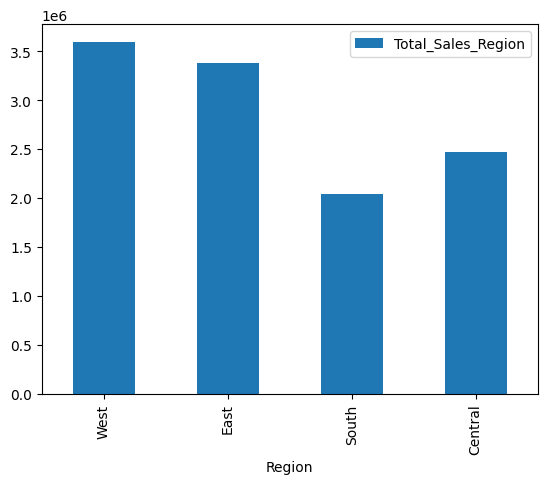

In [0]:
# Agrupa ventas por región para visualizar
sales_by_region = df.groupBy("Region").agg({"Total_Sales": "sum"}).withColumnRenamed("sum(Total_Sales)", "Total_Sales_Region")

# Muestra como gráfico de barras
sales_by_region.toPandas().plot(kind="bar", x="Region", y="Total_Sales_Region")

In [0]:

spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()
df = spark.table("superstore_transformed")
df.show(5)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+---------------+-----------+
|Row_ID|      Order_ID|Order_Date| Ship_Date|     Ship_Mode|Customer_ID|  Customer_Name|  Segment|      Country|           City|     State|Postal_Code|Region|     Product_ID|       Category|Sub-Category|        Product_Name|   Sales|Quantity|Discount|  Profit|Profit_Adjusted|Total_Sales|
+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+--------------------+--------+--------+--------+--------+---------------+-----------+
|     1|CA-2016-152156|2016-11-08|2016-11-11|  Second Class|   CG-12520|    Claire Gute| Consumer|United States|      Henderson|  Ken

In [0]:
# Selecciona features y label directamente, eliminando nulos
data = df.select("Quantity", "Discount", "Total_Sales").na.drop()

# Divide en train y test
train_data, test_data = data.randomSplit([0.8, 0.2])

# Muestra las primeras 5 filas para verificar
train_data.show(5)

+--------+--------+-----------+
|Quantity|Discount|Total_Sales|
+--------+--------+-----------+
|       1|     0.0|       0.99|
|       1|     0.0|       1.64|
|       1|     0.0|       1.68|
|       1|     0.0|       1.78|
|       1|     0.0|       1.81|
+--------+--------+-----------+
only showing top 5 rows


In [0]:
train_data.show(5)
test_data.show(5)

+--------+--------+-----------+
|Quantity|Discount|Total_Sales|
+--------+--------+-----------+
|       1|     0.0|       0.99|
|       1|     0.0|       1.64|
|       1|     0.0|       1.68|
|       1|     0.0|       1.78|
|       1|     0.0|       1.81|
+--------+--------+-----------+
only showing top 5 rows
+--------+--------+-----------+
|Quantity|Discount|Total_Sales|
+--------+--------+-----------+
|       1|     0.0|       1.24|
|       1|     0.0|        2.2|
|       1|     0.0|       2.88|
|       1|     0.0|       2.94|
|       1|     0.0|       3.04|
+--------+--------+-----------+
only showing top 5 rows


In [0]:

# Calcula el promedio de Total_Sales
avg_sales = df.select(avg("Total_Sales")).collect()[0][0]
print(f"Predicción básica (promedio de Total_Sales): {avg_sales}")

Predicción básica (promedio de Total_Sales): 1149.4959047328377


In [0]:

# Calculate baseline RMSE for average prediction
avg_sales = df.select(avg("Total_Sales")).collect()[0][0]

df_with_pred = df.withColumn("Prediction", lit(avg_sales))

rmse = df_with_pred.select(sqrt(mean((col("Total_Sales") - col("Prediction"))**2)).alias("RMSE")).collect()[0][0]
print(f"Baseline RMSE: {rmse}")

Baseline RMSE: 3898.471034700573


# Resumen General del Proyecto
- **Día 1:** Configuración, carga y exploración inicial del dataset Superstore.
- **Día 2:** Limpieza (nulos en Profit, ajuste negativos), transformación (Total_Sales, grouping por Region), y almacenamiento en Delta Lake "superstore_transformed".
- **Día 3:** Análisis SQL (top productos), visualización (barras por Region), y ML baseline (promedio Total_Sales ~1149.50, RMSE ~3898.47).
- **Insights Principales:** West lidera ventas (~3.6M), promedio ventas ~1149.50, RMSE baseline ~3898.
- **Desafíos:** Superados restricciones de Community Edition (e.g., ML whitelisting, rendering viz).
- **Recomendaciones:** Enfocarse en West, investigar sub-categories con bajo profit.